In [2]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers,models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

In [3]:
(Xtrain,ytrain),(Xtest,ytest) = cifar10.load_data()
vehicleCat = [0,1,8,9]  #vehicle class = 0
animalCat = [2,3,4,5,6,7] #animal class = 1

In [4]:
ytrainBinary = [(0 if i in vehicleCat else 1) for i in ytrain.flatten()]
ytestBinary = [(0 if i in vehicleCat else 1) for i in ytest.flatten()]

In [5]:
print(ytrainBinary)

[1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 

In [6]:
ytrainBinary = to_categorical(ytrainBinary,2)
ytestBinary = to_categorical(ytestBinary,2)
Xtrain = Xtrain/255
Xtest = Xtest/255
print(Xtrain.shape)
print(ytrainBinary.shape)

(50000, 32, 32, 3)
(50000, 2)


In [7]:
print(ytrainBinary)

[[0. 1.]
 [1. 0.]
 [1. 0.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [8]:
CNNmodel = models.Sequential([
    layers.Conv2D(32,(3,3),activation="relu",input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation="relu"),
    layers.Flatten(),
    layers.Dense(128,"relu"),
    layers.Dense(2,activation="softmax")
])

In [9]:
CNNmodel.compile(optimizer="adam",loss="categorical_crossentropy",metrics="accuracy")

In [10]:
fittedM = CNNmodel.fit(Xtrain,ytrainBinary,epochs=10,validation_data=(Xtest,ytestBinary))

Epoch 1/10
1563/1563 [==============================] - 17s 11ms/step - loss: 0.2844 - accuracy: 0.8829 - val_loss: 0.2252 - val_accuracy: 0.9084
Epoch 2/10
1563/1563 [==============================] - 16s 10ms/step - loss: 0.2208 - accuracy: 0.9120 - val_loss: 0.2324 - val_accuracy: 0.9042
Epoch 3/10
1563/1563 [==============================] - 17s 11ms/step - loss: 0.1935 - accuracy: 0.9239 - val_loss: 0.1844 - val_accuracy: 0.9292
Epoch 4/10
1563/1563 [==============================] - 16s 10ms/step - loss: 0.1705 - accuracy: 0.9334 - val_loss: 0.1802 - val_accuracy: 0.9289
Epoch 5/10
1563/1563 [==============================] - 17s 11ms/step - loss: 0.1523 - accuracy: 0.9419 - val_loss: 0.1724 - val_accuracy: 0.9312
Epoch 6/10
1563/1563 [==============================] - 18s 12ms/step - loss: 0.1322 - accuracy: 0.9485 - val_loss: 0.1637 - val_accuracy: 0.9353
Epoch 7/10
1563/1563 [==============================] - 19s 12ms/step - loss: 0.1140 - accuracy: 0.9556 - val_loss: 0.2037 -

In [11]:
loss,accuracy = CNNmodel.evaluate(Xtest,ytestBinary,verbose=2)
print(accuracy)

313/313 - 1s - loss: 0.2369 - accuracy: 0.9241 - 1s/epoch - 3ms/step
0.9240999817848206


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

313/313 [==============================] - 1s 3ms/step


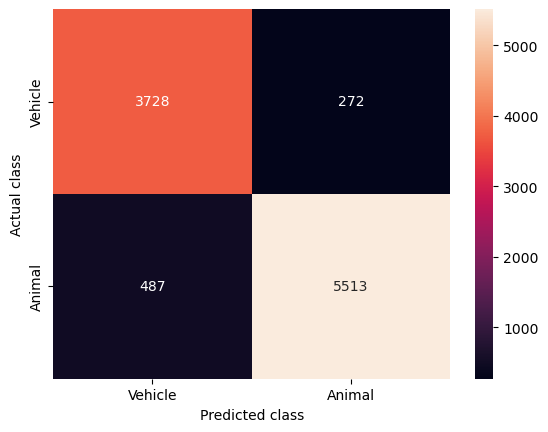

In [ ]:
ypred = CNNmodel.predict(Xtest)
ypredBinary = ypred[:,1].round().astype(int)
ytestBinary = ytestBinary.astype(int)
confusionM = confusion_matrix(ytestBinary,ypredBinary)
sns.heatmap(confusionM,annot=True,fmt="d", xticklabels=["Vehicle","Animal"],yticklabels=["Vehicle","Animal"])
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.show()

In [25]:
XtestFull = Xtest*255
misclass = []

for i in range(len(ypredBinary)):
    if ypredBinary[i] != ytestBinary[i]:
        misclass.append(i)

print(len(misclass))

759


Vehicle


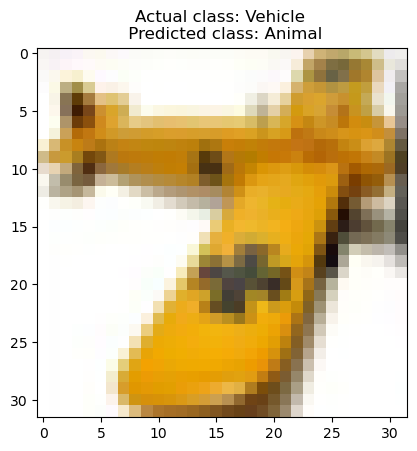

Vehicle


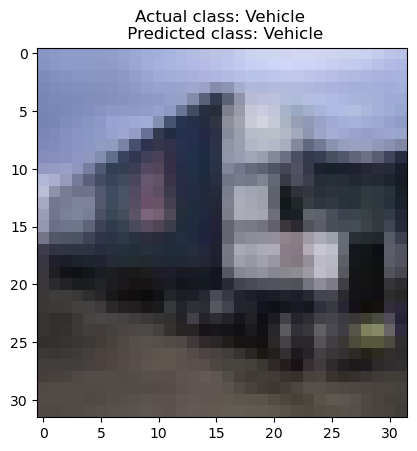

Vehicle


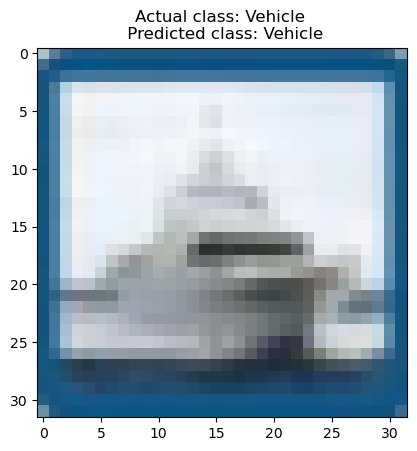

Vehicle


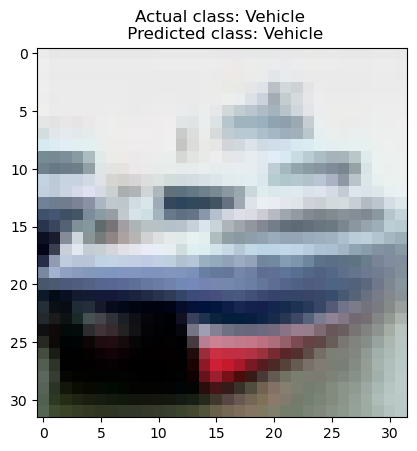

Animal


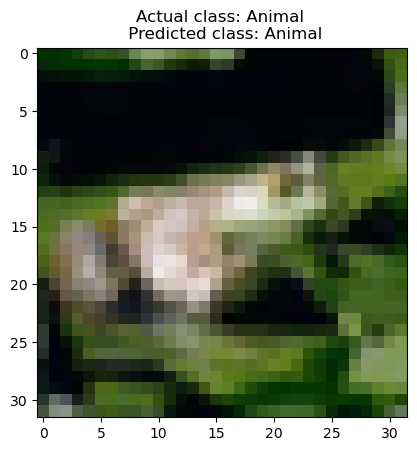

Animal


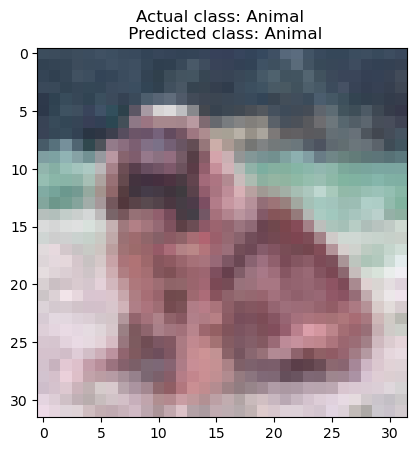

In [37]:
def visualise(index):
    plt.imshow(Xtest[index])
    actualLbl = "Animal" if ytestBinary[index] == 1 else "Vehicle"
    predLbl = "Animal" if ypredBinary[index] == 1 else "Vehicle"
    plt.title(f"Actual class: {actualLbl} \n Predicted class: {predLbl}")
    print(actualLbl)
    plt.show()

values = [678,34,875,1,62,101]
for i in values:
    visualise(i)